# Este notebook se propõe à fazer um modelo de detecção de exoplanetas com os dados obtidos da missão Kepler e do arquivo de exoplanetas da NASA.

🛰️ Dados coletados por:

Telescópio Espacial Kepler (2009–2018)

TESS (Satélite de Pesquisa de Exoplanetas em Trânsito) (2018–Presente)

# Fontes:

Arquivo de Exoplanetas da NASA, IPAC, Caltech. "Arquivo de Exoplanetas da NASA." NExScI (2023). DOI: 10.26133/NEA1

Thompson et al. (2018). "Métricas de detecção de planetas: Métricas resumidas para a versão 25 dos dados do Kepler."

Twicken et al. (2016). "Manual de Processamento de Dados Kepler: Módulo de Pipeline de Condicionamento de Dados de Pré-busca."

# Importartar Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Carregar Conjutos de dados

In [16]:
# Usando caminhos relativos
caminho_keplerstellar = "archive/keplerstellar_2025.02.03_04.41.47.csv"
caminho_stellarhosts = "archive/STELLARHOSTS_2025.02.03_06.11.17.csv"
caminho_koi = "archive/q1_q8_koi_2025.02.03_04.12.15.csv"
caminho_tce = "archive/q1_q17_dr25_tce_2025.02.03_04.32.18.csv"
caminho_ps = "archive/PS_2025.02.03_05.09.36.csv"
caminho_prob_falso_positivo = "archive/q1_q17_dr25_koifpp_2025.02.03_06.14.34.csv"
caminho_toi = "archive/TOI_2025.02.03_06.18.31.csv"

# Carregando com o parâmetro comment='#' para ignorar os cabeçalhos de texto
estrelas_kepler = pd.read_csv(caminho_keplerstellar, comment='#')
estrelas_hospedeiras = pd.read_csv(caminho_stellarhosts, comment='#')

tabela_koi = pd.read_csv(caminho_koi, comment='#')
tabela_tce = pd.read_csv(caminho_tce, comment='#')
tabela_sistemas_planetarios = pd.read_csv(caminho_ps, comment='#')

tabela_prob_falso_positivo = pd.read_csv(caminho_prob_falso_positivo, comment='#')
tabela_toi = pd.read_csv(caminho_toi, comment='#')

# Explorar dados
Estatísticas básicas e visão geral

In [10]:
# Checando informações gerais das tabelas
print("KOI Table Overview:\n", tabela_koi.info())
print("TCE Table Overview:\n", tabela_tce.info())

# Checando valores ausentes nas tabelas
print("Missing Values:\n", tabela_koi.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 3865 entries, 0 to 3864
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kepid              3865 non-null   int64  
 1   kepoi_name         3865 non-null   str    
 2   kepler_name        2319 non-null   str    
 3   koi_disposition    3865 non-null   str    
 4   koi_pdisposition   3865 non-null   str    
 5   koi_score          0 non-null      float64
 6   koi_fpflag_nt      0 non-null      float64
 7   koi_fpflag_ss      0 non-null      float64
 8   koi_fpflag_co      0 non-null      float64
 9   koi_fpflag_ec      0 non-null      float64
 10  koi_period         3865 non-null   float64
 11  koi_period_err1    3845 non-null   float64
 12  koi_period_err2    3845 non-null   float64
 13  koi_time0bk        3865 non-null   float64
 14  koi_time0bk_err1   3845 non-null   float64
 15  koi_time0bk_err2   3845 non-null   float64
 16  koi_impact         3865 non-null   

Exemplos de candidatos a exoplanetas

In [ ]:
# Exibindo as primeiras linhas da tabela KOI
tabela_koi.head()

,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,9388479,K00936.02,Kepler-732 c,CONFIRMED,CANDIDATE,NaN,NaN,NaN,NaN,NaN,...,-200.0,4.76,0.3,-0.3,0.496,0.023,-0.023,283.73203,45.958771,15.073
1,8359498,K00127.01,Kepler-77 b,CONFIRMED,CANDIDATE,NaN,NaN,NaN,NaN,NaN,...,-50.0,4.45,0.1,-0.1,1.039,0.045,-0.045,289.60797,44.345421,13.938
2,9406990,K00937.01,Kepler-733 b,CONFIRMED,CANDIDATE,NaN,NaN,NaN,NaN,NaN,...,-102.0,4.60,0.3,-0.3,0.780,0.240,-0.240,293.01828,45.914688,15.412
3,9415172,K00938.01,Kepler-255 c,CONFIRMED,CANDIDATE,NaN,NaN,NaN,NaN,NaN,...,-128.0,4.58,0.3,-0.3,0.800,0.380,-0.380,296.06424,45.976841,15.596
4,9415172,K00938.02,Kepler-255 d,CONFIRMED,CANDIDATE,NaN,NaN,NaN,NaN,NaN,...,-128.0,4.58,0.3,-0.3,0.800,0.380,-0.380,296.06424,45.976841,15.596


# Visualizando dados de exoplanetas
 Distribuição dos Períodos Orbitais dos Exoplanetas

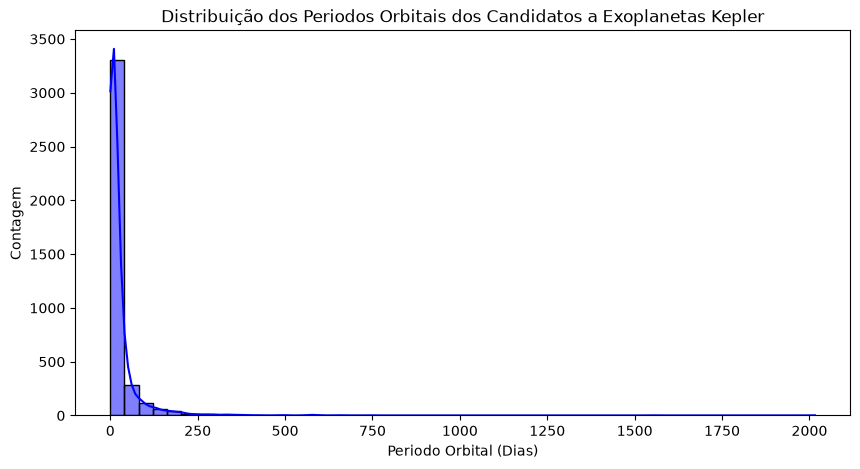

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(tabela_koi["koi_period"], bins=50, kde=True, color="blue")
plt.xlabel("Periodo Orbital (Dias)")
plt.ylabel("Contagem")
plt.title("Distribuição dos Periodos Orbitais dos Candidatos a Exoplanetas Kepler")
plt.show()

# Temperatura Estelar vs. Raio Planetário

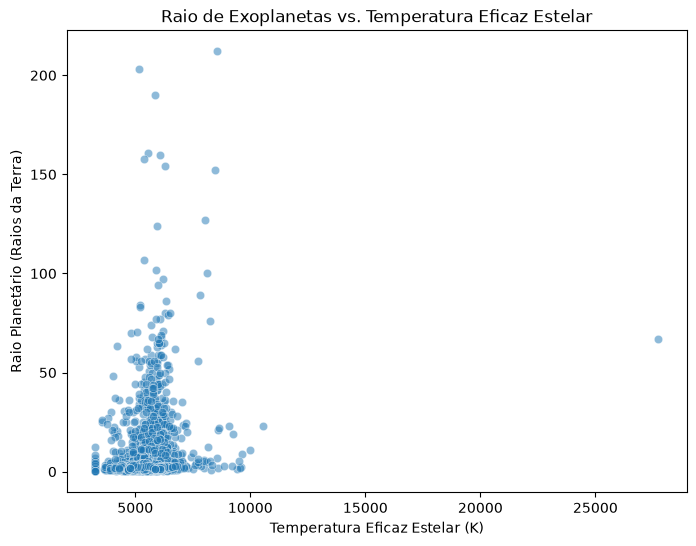

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=tabela_koi, x="koi_steff", y="koi_prad", alpha=0.5)
plt.xlabel("Temperatura Eficaz Estelar (K)")
plt.ylabel("Raio Planetário (Raios da Terra)")
plt.title("Raio de Exoplanetas vs. Temperatura Eficaz Estelar")
plt.show()

# Identificando possíveis falsos positivos

In [21]:
# Unir dados de KOI com dados de FPP
koi_fpp = pd.merge(tabela_koi, tabela_prob_falso_positivo, on="kepid", how="left")

# Filtrar candidatos com altas probabilidades de serem falsos positivos
alta_prob_falso_positivo = koi_fpp[koi_fpp["fpp_prob"] > 0.5]

# Exibir potenciais falsos positivos
alta_prob_falso_positivo[["kepid", "koi_period", "koi_prad", "fpp_prob"]].head()

,kepid,koi_period,koi_prad,fpp_prob
37,10158990,1.096584,1.40,1.00
39,10149023,9.955121,2.20,1.00
54,10148521,1.204274,1.24,0.54
55,5481416,2.384054,2.50,1.00
64,5534814,4.859384,13.20,1.00
